#  Climate Change and Extreme Weather Events

**Research Question:** How have the frequency and economic damage of extreme weather events changed
over the past 50 years, and which world regions show the steepest acceleration?

## 1. Configuração e Obtenção de Dados

In [124]:
# Bibliotecas
import os
import glob
import pandas as pd
import seaborn as sns
import missingno as msno
import pycountry_convert as pc
import matplotlib.pyplot as plt

In [125]:
# Funções
# Filtrar apenas os dados relativos a regiões (continentes) do planeta
def country_to_continent(country_code):
    # TLS: Timor-Leste (Asia), SXM: Sint Maarten (North America)
    # YMN: Yemen Arab Republic (Asia), DFR: Germany Federal Republic (Europe)
    # YMD: People's Democratic Republic of Yemen (Asia), YUG: Yugoslavia (Europe)
    # CSK: Czechoslovakia (Europe), SUN: Soviet Union (Europe),
    # DDR: German Democratic Republic (Europe), AZO: Azores Islands (Europe)
    # ANT: Netherlands Antilles (South America), SCG: Serbia Montenegro (Europe)
    # SPI: Canary Islands (Africa)

    ukn_asia = ['YMN', 'TLS', 'YMD']
    ukn_europe = ['AZO', 'DFR', 'YUG', 'CSK', 'SUN', 'DDR', 'SCG']
    try:
        country_code_alpha2 = pc.country_alpha3_to_country_alpha2(country_code)
        continent_code = pc.country_alpha2_to_continent_code(country_code_alpha2)
        continent_name = pc.convert_continent_code_to_continent_name(continent_code)
        return continent_name
    except Exception:
        if country_code == 'SPI':
            return "Africa"
        if country_code in ukn_asia:
            return "Asia"
        if country_code in ukn_europe:
            return "Europe"
        if country_code == 'ANT':
            return "South America"
        if country_code == 'SXM':
            return "North America"
        print(f"Erro ao converter {country_code}.")
        return "Other/Unknown"
    
# Exibir a quantidade e a porcentagem de valores ausentes por coluna
def show_missing_values(df):
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(1)
    summary = pd.DataFrame({
        'missing_count': missing,
        'missing_pct': pct
    })

    if summary['missing_count'].sum() == 0:
        print("Não há valores ausentes no dataset.")
    else:
        print("Valores ausentes por coluna:")
        print(summary[summary['missing_count'] > 0])

# Exibir a quantidade e a porcentagem de linhas duplicadas
def show_duplicate_lines(df):
    n_duplicates = df.duplicated().sum()
    duplicates_per = n_duplicates/len(df) * 100

    print(f"Linhas duplicadas: {n_duplicates} ({duplicates_per:.2f}%)")

In [126]:
path = '../data'
files = glob.glob(os.path.join(path, "*.csv"))
df_list = [pd.read_csv(f) for f in files]

extreme_weather_events   = df_list[0]
greenhouse_gas_emissions = df_list[1]
surface_temperature      = df_list[2]
temperature_anomalies    = df_list[3]

## 2. Limpeza e Filtragem (Data Cleaning)

* **Tipos de Eventos:** Droughts, Floods, Storms, Extreme Temperatures e Wildfires.
* **Recorte Temporal:** 1975 a 2024 (50 anos).
* **Agrupamento Geográfico:** África, Ásia, Europa, América do Norte, América do Sul e Oceania.

### 2.1. Análise do dataset **Extreme weather events**

Pre-2000 data is particularly subject to reporting biases.

In [127]:
rows, cols = extreme_weather_events.shape

print(f"O dataframe tem: {rows} linhas e {cols} colunas.")

show_duplicate_lines(extreme_weather_events)

print(extreme_weather_events.columns.to_list())

O dataframe tem: 11768 linhas e 8 colunas.
Linhas duplicadas: 157 (1.33%)
['Year', 'Disaster Type', 'ISO', 'Country', 'Region', 'Total Deaths', 'Total Affected', 'Adjusted Total Damage (K US$)']


In [128]:
print(extreme_weather_events.Region.unique().tolist())
extreme_weather_events

['Africa', 'Asia', 'Oceania', 'Americas', 'Europe']


,Year,Disaster Type,ISO,Country,Region,Total Deaths,Total Affected,Adjusted Total Damage (K US$)
0,1975,Flood,KEN,Kenya,Africa,NaN,16000.0,NaN
1,1975,Flood,THA,Thailand,Asia,239.0,3000093.0,262298.0
2,1975,Storm,MDG,Madagascar,Africa,7.0,10050.0,NaN
3,1975,Storm,FJI,Fiji,Oceania,NaN,23000.0,5829.0
4,1975,Flood,MOZ,Mozambique,Africa,1.0,75000.0,NaN
...,...,...,...,...,...,...,...,...
11763,2000,Storm,REU,Réunion,Africa,2.0,600.0,NaN
11764,2000,Storm,IRN,Iran (Islamic Republic of),Asia,3.0,5500.0,NaN
11765,1999,Drought,UGA,Uganda,Africa,115.0,700000.0,NaN
11766,2000,Drought,SOM,Somalia,Africa,21.0,1200000.0,NaN


Como este dataset não faz a distinção entre América do Norte e do Sul, precisamos fazer uma tranformação, como base no código ISO dos países, mas que esta divisão fique correta. Em seguida eliminamos as colunas ISO e Country, para facilitar os processos seguintes.

In [129]:
extreme_weather_events['Region'] = extreme_weather_events['ISO'].apply(country_to_continent)
print(extreme_weather_events.Region.unique().tolist())
extreme_weather_events.drop(columns=['ISO', 'Country'], inplace=True)
extreme_weather_events.head()

['Africa', 'Asia', 'Oceania', 'North America', 'South America', 'Europe']


,Year,Disaster Type,Region,Total Deaths,Total Affected,Adjusted Total Damage (K US$)
0,1975,Flood,Africa,NaN,16000.0,NaN
1,1975,Flood,Asia,239.0,3000093.0,262298.0
2,1975,Storm,Africa,7.0,10050.0,NaN
3,1975,Storm,Oceania,NaN,23000.0,5829.0
4,1975,Flood,Africa,1.0,75000.0,NaN


In [130]:
show_missing_values(extreme_weather_events)

Valores ausentes por coluna:
                               missing_count  missing_pct
Total Deaths                            3637         30.9
Total Affected                          2842         24.2
Adjusted Total Damage (K US$)           7355         62.5


<Axes: >

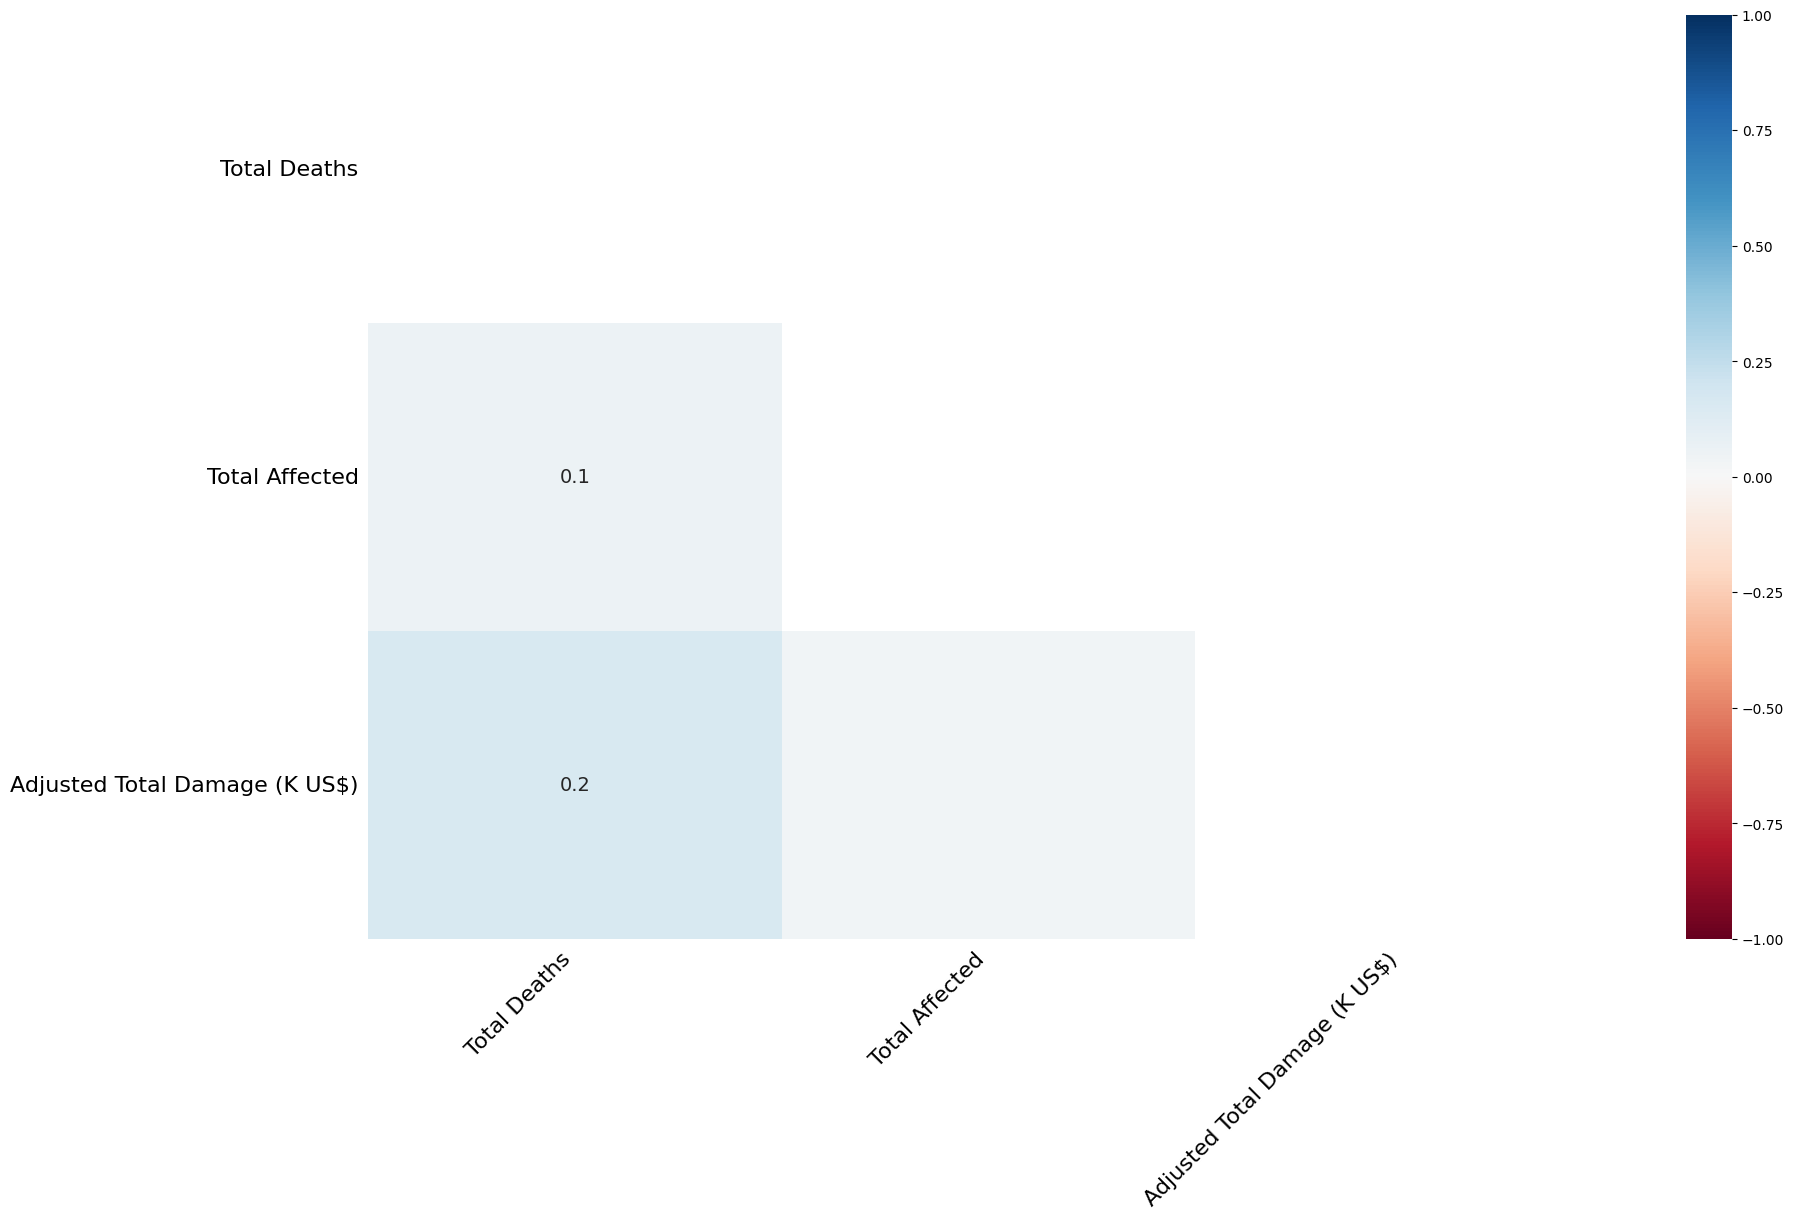

In [131]:
msno.heatmap(extreme_weather_events)

Ao analisar o heatmap acima, chegamos à conclusão que, devido aos valores próximos de 0 (zero), podemos afirmar que não há relação entre a ausência de dados das colunas.

Para melhor analisar os efeitos dos eventos climáticos extremos, resolvemos separá-los de acordo com o impacto causado (Total Deaths, Total Affected e Adjusted Total Damage).

In [132]:
ewe_deaths = extreme_weather_events.drop(columns=['Total Affected', 'Adjusted Total Damage (K US$)'])
ewe_affected = extreme_weather_events.drop(columns=['Total Deaths', 'Adjusted Total Damage (K US$)'])
ewe_damage = extreme_weather_events.drop(columns=['Total Deaths', 'Total Affected'])

#### 2.1.1 Análise do subdataset **Extreme weather events - Total Deaths**

In [133]:
show_missing_values(ewe_deaths)

Valores ausentes por coluna:
              missing_count  missing_pct
Total Deaths           3637         30.9


Este subdataset tem 3.637 valores vazios (30.9%). Contudo, como nem todo evento causa mortes, resolvemos preencher os valores vazios com 0 (zero), indicando que não houve mortes nestes desastres.

In [135]:
ewe_deaths = ewe_deaths.fillna(0)
ewe_deaths['Total Deaths'] = ewe_deaths['Total Deaths'].astype(int)
show_missing_values(ewe_deaths)
ewe_deaths.head()

Não há valores ausentes no dataset.


,Year,Disaster Type,Region,Total Deaths
0,1975,Flood,Africa,0
1,1975,Flood,Asia,239
2,1975,Storm,Africa,7
3,1975,Storm,Oceania,0
4,1975,Flood,Africa,1


#### 2.1.2 Análise do subdataset **Extreme weather events - Total Affected**

In [145]:
show_missing_values(ewe_affected)

Valores ausentes por coluna:
                missing_count  missing_pct
Total Affected           2842         24.2


In [144]:
# Contagem para o período de 1975 a 1999
vazios_75_99 = ewe_affected.loc[ewe_affected['Year'] <= 1999, 'Total Affected'].isna().sum()

# Contagem para o período de 2000 a 2024
vazios_00_24 = ewe_affected.loc[ewe_affected['Year'] >= 2000, 'Total Affected'].isna().sum()

print(f"Linhas vazias (1975-1999): {vazios_75_99}")
print(f"Linhas vazias (2000-2024): {vazios_00_24}")

Linhas vazias (1975-1999): 1164
Linhas vazias (2000-2024): 1678


Apesar do aviso do EM-DAT de que os valores anteriores a 2000 estão mais sujeitos à vieses, como a quantidade de valores vazions na coluna de total de afetados é maior no período após os anos 2000, então passamos a considerar como 0 (zero), a quantidade de pessoas afetadas nos registros vazios.

In [146]:
ewe_affected = ewe_affected.fillna(0)
ewe_affected['Total Affected'] = ewe_affected['Total Affected'].astype(int)
show_missing_values(ewe_affected)
ewe_affected.head()

Não há valores ausentes no dataset.


,Year,Disaster Type,Region,Total Affected
0,1975,Flood,Africa,16000
1,1975,Flood,Asia,3000093
2,1975,Storm,Africa,10050
3,1975,Storm,Oceania,23000
4,1975,Flood,Africa,75000
